In [25]:
import pandas as pd

In [26]:
df = pd.read_csv("student_marks.csv")
df.head()

,Hours,Marks
0,1,20
1,2,30
2,3,40
3,4,50
4,5,60


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Hours   10 non-null     int64
 1   Marks   10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


In [28]:
df.describe()

,Hours,Marks
count,10.00000,10.00000
mean,5.50000,63.50000
std,3.02765,28.09211
min,1.00000,20.00000
25%,3.25000,42.50000
50%,5.50000,65.00000
75%,7.75000,87.50000
max,10.00000,100.00000


In [29]:
df.isnull().sum()

Hours    0
Marks    0
dtype: int64

In [30]:
import matplotlib.pyplot as plt

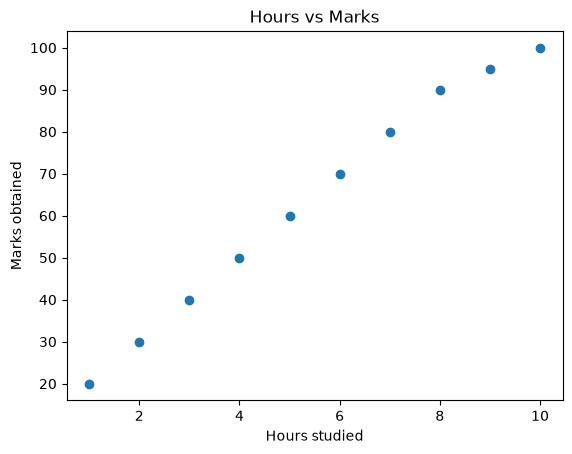

In [31]:
plt.scatter(df["Hours"],df["Marks"])
plt.xlabel("Hours studied")
plt.ylabel("Marks obtained")
plt.title("Hours vs Marks")
plt.show()

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#Input and Output
X = df[["Hours"]]
y = df["Marks"]

#Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.4, random_state=52)

In [33]:
#create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [34]:
#Predict the marks

predictions = model.predict(X_test)
print("Predicted Marks:", predictions)

Predicted Marks: [110.  30. 100.  50.]


In [35]:
#Compare Actual and Predicted
comparision = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": predictions
})
comparision

,Actual Marks,Predicted Marks
0,100,110.0
1,30,30.0
2,95,100.0
3,50,50.0


In [38]:
#model accuracy
from sklearn.metrics import r2_score
accuracy = r2_score(y_test, predictions)
print("R2 Score:", accuracy)

R2 Score: 0.9644760213143873


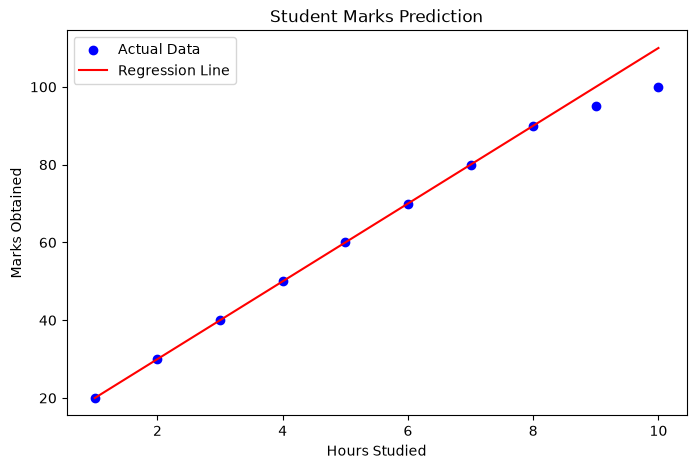

In [39]:
#Regression Line
plt.figure(figsize=(8,5))
plt.scatter(df["Hours"], df["Marks"], color="blue", label="Actual Data")
plt.plot(df["Hours"], model.predict(X), color="red", label="Regression Line")

plt.xlabel("Hours Studied")
plt.ylabel("Marks Obtained")
plt.title("Student Marks Prediction")
plt.legend()
plt.show()

In [21]:
#predict for a new student
new_hours = [[8.2]]
predicted_marks = model.predict(new_hours)
print("Predicted Marks:", predicted_marks[0])

Predicted Marks: 91.99999999999997


d:\Student-Marks-predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
import pickle
with open("student_marks_model.pkl","wb") as file:
    pickle.dump(model,file)

print("Model saved successfully!")

Model saved successfully!
